# Exercise - Monthly Job Demand
___
- We are going to dive into Inspecting, what is the Demand of certain Job Titles over the course of a year specificaly to United States and Canada
- The Graph we will be building will be following on from a couple of key Concepts of what we just learned
    - Being able to Group our Data: By Month and Job Title
    - Sorting it properly so we can get the Months in the proper order

### Exercise: Analyzing Data Science Job Demand

In [1]:
# Imports
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

In [12]:
# Create a New Data Frame and Filter the Country. Adding copy at the end so it's completely Unique (Won't Alter the Original)
df_US = df[df['job_country'] == "United States"].copy()

# Another one for Canada
df_Canada = df[df['job_country'] == "Canada"].copy()

# Print it out to inspect it
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',..."
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '..."
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['..."
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,NaN,NaN
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['..."
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}"
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN


- With our Data Frame, we are now going to Extract out the Month Values from this
- These are all from 2023 but we only want the Month
    - But we don't want the Month Value/Number, we want the actual Name of the Month, I.E. January
    - To do this, we Create a New Column for the Month Name in our new Data Frame
    - Set it Equal to the New Data Frame and Access the Correct Column
    - Using `dt.strftime` (string format time) to Convert datetime Objects into Readable Strings based on the Provided Format
    - Supply the Format that gives us the String Value back
- Finally Printing it out to see our work (and ofc doing it twice because we want to see US and Canada)

In [15]:
# Creating a New Column and Extrating out the Month Name from the job_posted_date
df_US['job_posted_month'] = df_US['job_posted_date'].dt.strftime('%B')

# Doing the same for Canada
df_Canada['job_posted_month'] = df_Canada['job_posted_date'].dt.strftime('%B')

# Inspecting and showing our work
df_US

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills,job_posted_month
0,Senior Data Engineer,Senior Clinical Data Engineer / Principal Clin...,"Watertown, CT",via Work Nearby,Full-time,False,"Texas, United States",2023-06-16 13:44:15,False,False,United States,NaN,NaN,NaN,Boehringer Ingelheim,NaN,NaN,June
3,Data Engineer,LEAD ENGINEER - PRINCIPAL ANALYST - PRINCIPAL ...,"San Antonio, TX",via Diversity.com,Full-time,False,"Texas, United States",2023-07-04 13:01:41,True,False,United States,NaN,NaN,NaN,Southwest Research Institute,"['python', 'c++', 'java', 'matlab', 'aws', 'te...","{'cloud': ['aws'], 'libraries': ['tensorflow',...",July
5,Data Engineer,GCP Data Engineer,Anywhere,via ZipRecruiter,Contractor and Temp work,True,Georgia,2023-11-07 14:01:59,False,False,United States,NaN,NaN,NaN,smart folks inc,"['python', 'sql', 'gcp']","{'cloud': ['gcp'], 'programming': ['python', '...",November
6,Senior Data Engineer,Senior Data Engineer - GCP Cloud,"Dearborn, MI",via LinkedIn,Full-time,False,"Florida, United States",2023-03-27 13:18:18,False,False,United States,NaN,NaN,NaN,"Miracle Software Systems, Inc","['sql', 'python', 'java', 'sql server', 'gcp',...","{'cloud': ['gcp', 'bigquery'], 'databases': ['...",March
9,Data Scientist,Data Scientist II,Anywhere,via ZipRecruiter,Full-time,True,"New York, United States",2023-04-23 13:02:57,False,False,United States,NaN,NaN,NaN,"Radwell International, LLC","['sql', 'python', 'r', 'mongodb', 'mongodb', '...","{'analyst_tools': ['excel'], 'cloud': ['azure'...",April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
785673,Data Scientist,Asset Management Data Scientist,"New York, NY",via Trabajo.org,Full-time,False,"New York, United States",2023-10-16 06:01:53,True,False,United States,NaN,NaN,NaN,JPMorgan Chase & Co.,NaN,NaN,October
785685,Data Analyst,Data Analyst,"Indianapolis, IN",via Trabajo.org,Full-time,False,"Illinois, United States",2023-07-16 06:01:27,True,False,United States,NaN,NaN,NaN,"Aara Technologies, Inc","['sql', 'excel']","{'analyst_tools': ['excel'], 'programming': ['...",July
785692,Data Scientist,Data Scientist- Hybrid Work Location,"Dayton, OH",via Ai-Jobs.net,Full-time,False,"Illinois, United States",2023-04-21 06:02:31,False,True,United States,year,157500.0,NaN,Tenet3,"['python', 'matlab', 'r']","{'programming': ['python', 'matlab', 'r']}",April
785703,Data Analyst,Data Analyst - CRYPTOGRAPHY - Full-time,Anywhere,via Snagajob,Full-time,True,"Texas, United States",2023-01-28 06:02:55,True,False,United States,NaN,NaN,NaN,Axelon Services Corporation,NaN,NaN,January


- Now we need to Pivot the Data in order to get it in a Format necessary to Plot it
    - Specifically, we want to Plot `job_months` along the **Index** (For a Specific Reason(Which is because of the Index and so we Reset the Index and Sort it, to Reset it again))
    - Along the **Columns** we are going to put the different `job_titles`
    - Going to be Aggregating the **Count** of these different Jobs over time
    - Also, set the Pivot to a Variable so it can be Plotted
        - After Running, we get what we want but we have a small problem that we need to Clean-up
        - `job_posted_month` is in Alphabetical Order, not Chronological Order... which is no use to us as it's un-plottable because it won't make sense on the Visual
        - We can Sort this, but it would only be Ascending/Descending, there's nothing in there that we can use to Sort it Chronologically
        - Now we need to get out, for the different `job_posted_month`, we need the actual Number associated with the `job_posting_month` and the Sort it by that
        - Need to get it where 1 = January, 2 = Februart, etc...

In [32]:
# Creating a Pivot Table on the Data Frame to Group By Months, Sort by Job Titles and Aggregate by the Count
df_US_pivot = df_US.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

# Doing the same thing for Canada
df_Canada_pivot = df_Canada.pivot_table(index='job_posted_month', columns='job_title_short', aggfunc='size')

# Printing out our Work
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
April,565,40,6049,2801,4867,51,1025,781,991,112
August,903,39,6634,3269,6318,68,1186,903,1515,194
December,648,40,3979,2641,3472,119,601,689,752,212
February,447,24,6124,3060,4956,56,1258,878,1127,90
January,527,36,8494,2655,6915,60,1544,773,1552,114
July,581,39,5201,2570,4876,65,883,747,1095,153
June,446,32,5683,2893,4645,48,1009,812,1033,93
March,438,19,6218,3183,4779,59,1114,829,1150,115
May,279,20,4993,2976,4377,49,839,746,914,90


- First thing we are going to do is Reset the Index
    - This is to push the Month in, so that when we add the Numbers in, we can then Sort it by those Numbers
- Also adding in the `inplace=True` to make it affect the Variable and override it (This is instead of having the Variable equal itself)

In [64]:
# Re-setting the Index
df_US_pivot.reset_index(inplace=True)

# Again doing it for Canada
df_Canada_pivot.reset_index(inplace=True)

# Printing out our work
df_US_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
0,January,527,36,8494,2655,6915,60,1544,773,1552,114
1,February,447,24,6124,3060,4956,56,1258,878,1127,90
2,March,438,19,6218,3183,4779,59,1114,829,1150,115
3,April,565,40,6049,2801,4867,51,1025,781,991,112
4,May,279,20,4993,2976,4377,49,839,746,914,90
5,June,446,32,5683,2893,4645,48,1009,812,1033,93
6,July,581,39,5201,2570,4876,65,883,747,1095,153
7,August,903,39,6634,3269,6318,68,1186,903,1515,194
8,September,897,50,4639,3224,4568,113,805,775,1014,228
9,October,932,48,5271,3015,4882,101,871,672,987,219


- Now we can see that it's Flattened out and now `job_posted_month` is in the Table
- And we can see that the Index has been Added
- Now we need to Create a New Column to Display the Number of the Job Month
    - Creating this on the `df_US_pivot` Data Frame called `month_number`
    - Just like when we Cleaned up the Data in the beginnning using the `pd.to_datetime()` Function, we are going to do the same thing here
    - Instead, we are Providing the Month Name, along with specifying how we previously Formatted so it knows what's going on. We had Formatted it with the `%B` to get the String Value
    - Running this, gives us the correct Monthly Number Value, but because we didn't explicitly define a Year or Date, it sets the Year to 1900 and the Date to the 1st by Default
    - Now, all we need to do is Extract out **only the Month Value**
        - To do this we use the `.dt` Accessor and specify that we just want the `month`
    - Running this now, we get the Month Value back

In [65]:
# Creating a New Column to get the Month Number Value
df_US_pivot['month_number'] = pd.to_datetime(df_US_pivot['job_posted_month'], format='%B').dt.month

# Doing it again for Canada
df_Canada_pivot['month_number'] = pd.to_datetime(df_Canada_pivot['job_posted_month'], format='%B').dt.month

# Printing out the Data Frame to see our New Column Added with the correct Values
df_US_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_number
0,January,527,36,8494,2655,6915,60,1544,773,1552,114,1
1,February,447,24,6124,3060,4956,56,1258,878,1127,90,2
2,March,438,19,6218,3183,4779,59,1114,829,1150,115,3
3,April,565,40,6049,2801,4867,51,1025,781,991,112,4
4,May,279,20,4993,2976,4377,49,839,746,914,90,5
5,June,446,32,5683,2893,4645,48,1009,812,1033,93,6
6,July,581,39,5201,2570,4876,65,883,747,1095,153,7
7,August,903,39,6634,3269,6318,68,1186,903,1515,194,8
8,September,897,50,4639,3224,4568,113,805,775,1014,228,9
9,October,932,48,5271,3015,4882,101,871,672,987,219,10


- After doing some quick fact checking to make sure this is correct and the correct number is assigned to the correct Month
    - Checking the first line we can see, April has the Number 4, which is correct. Verified that this is now good and Displaying correctly
- Now we need to Sort our Values by the `mounth_number`

In [66]:
# Sorting the Values by the Month Number
df_US_pivot.sort_values('month_number', inplace=True)

# Doing the same for Canada
df_Canada_pivot.sort_values('month_number', inplace=True)

# Printing it out to Verify we did it correctly
df_US_pivot

job_title_short,job_posted_month,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_number
0,January,527,36,8494,2655,6915,60,1544,773,1552,114,1
1,February,447,24,6124,3060,4956,56,1258,878,1127,90,2
2,March,438,19,6218,3183,4779,59,1114,829,1150,115,3
3,April,565,40,6049,2801,4867,51,1025,781,991,112,4
4,May,279,20,4993,2976,4377,49,839,746,914,90,5
5,June,446,32,5683,2893,4645,48,1009,812,1033,93,6
6,July,581,39,5201,2570,4876,65,883,747,1095,153,7
7,August,903,39,6634,3269,6318,68,1186,903,1515,194,8
8,September,897,50,4639,3224,4568,113,805,775,1014,228,9
9,October,932,48,5271,3015,4882,101,871,672,987,219,10


- Now, we have it Sorted by the `month_number`
- Next thing we need to do now, is actually Set the Index of this
    - To do this, we want to use `.set_index('job_posted_month')`
    - This will Set the Index back to the Job Month String Value but now Sorted Chronologically

In [67]:
# Setting the Index of the Data Frame to the now Chronologically Sorted Month String Value
df_US_pivot.set_index('job_posted_month', inplace=True)

# Doing the same for Canada
df_Canada_pivot.set_index('job_posted_month', inplace=True)

# Printing out the Data Frame
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer,month_number
job_posted_month,,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114,1
February,447,24,6124,3060,4956,56,1258,878,1127,90,2
March,438,19,6218,3183,4779,59,1114,829,1150,115,3
April,565,40,6049,2801,4867,51,1025,781,991,112,4
May,279,20,4993,2976,4377,49,839,746,914,90,5
June,446,32,5683,2893,4645,48,1009,812,1033,93,6
July,581,39,5201,2570,4876,65,883,747,1095,153,7
August,903,39,6634,3269,6318,68,1186,903,1515,194,8
September,897,50,4639,3224,4568,113,805,775,1014,228,9


- Now we can see, it's now Sorted by the Months, they are in the correct Chronological Order!
    - But now, we have this `month_number` Column in our Pivot Table that we don't need
    - We will need to get rid of it
    - To do this, we manipulate the Data Frame we are working in (`df_US_pivot`)
    - We invoke the `.drop()` Method
    - Specify the Column we want to Drop which is `columns='month_number'`
    - And don't forget to add `inaplce=True` in there as well

In [ ]:
# Dropping the month_number Column
df_US_pivot.drop(columns='month_number', inplace=True)

# Doing the same for Canada
df_Canada_pivot.drop(columns='month_number', inplace=True)

# Printing out our work
df_US_pivot

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_posted_month,,,,,,,,,,
January,527,36,8494,2655,6915,60,1544,773,1552,114
February,447,24,6124,3060,4956,56,1258,878,1127,90
March,438,19,6218,3183,4779,59,1114,829,1150,115
April,565,40,6049,2801,4867,51,1025,781,991,112
May,279,20,4993,2976,4377,49,839,746,914,90
June,446,32,5683,2893,4645,48,1009,812,1033,93
July,581,39,5201,2570,4876,65,883,747,1095,153
August,903,39,6634,3269,6318,68,1186,903,1515,194
September,897,50,4639,3224,4568,113,805,775,1014,228


- Now, after Running all that, we have our Job Posted Dates as the Month and that is now Set as the **Index** like we wanted
- So it's going to make Plaotting this super easy
- Along with all of our different Job Titles as **Columns** up the top
- Now, we can go ahead and jump right into Plotting this

<Axes: xlabel='job_posted_month'>

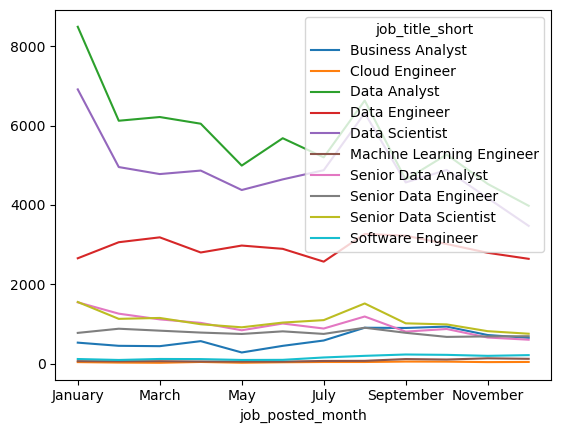

In [74]:
# Plotting our US Pivot Table Data Frame
df_US_pivot.plot(kind='line')

<Axes: xlabel='job_posted_month'>

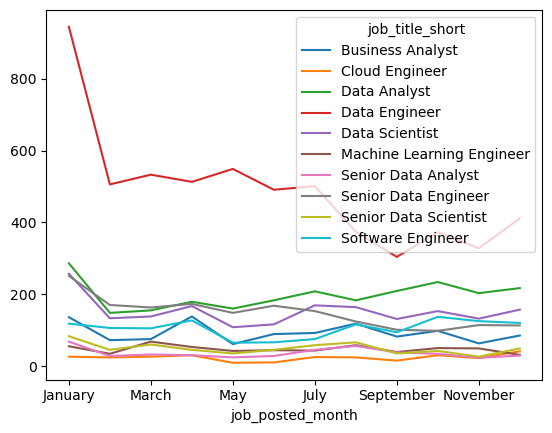

In [75]:
# Plotting our Canada Pivot Table Data Frame
df_Canada_pivot.plot(kind='line')

- Looking at this it looks absolutely disgusting
- It's very messy, hard to read and the amount of Data in both of these Charts is a little overwhelming with the amount of Data being Displayed...
- But! At least the Months are in Order, and all 8 of the Job Titles are on there
    - Even if it is a little cluttered...
- Now we get into the fun part!! The clean-up and making it look all nice
    - We will start by:
        - Displaying the Top 3 Jobs that have the most Counts
        - Giving Titles to the Visualizations and the Axes
        - Getting rid of the tag above the Visualization
        - Rotate the Month Labels as well
- To do this, we will First need to get the Top 3 Jobs that have the most Counts
    - All we need to do is get a List of the Top 3
    - We want to get it into a List because then we can use it to Filter the Data Frame further 

In [98]:
# Getting the Top 3 Jobs that have the most Counts
top_3_US = df_US['job_title_short'].value_counts().head(3)

# Only Returning the Index Value because we don't need the Counts and Converting it into a List
top_3_US = top_3_US.index.to_list()

# Doing the same for Canada
top_3_Canada = df_Canada.job_title_short.value_counts().head(3)

top_3_Canada = top_3_Canada.index.to_list()

# Printing out our work
print('Top US Jobs:       ', top_3_US)
print('Top Canadian Jobs: ', top_3_Canada)

Top US Jobs:        ['Data Analyst', 'Data Scientist', 'Data Engineer']
Top Canadian Jobs:  ['Data Engineer', 'Data Analyst', 'Data Scientist']


- Now whenever we go into Plot this, we can specify inside of Brackets our `top_3_US` or `top_3_Canada` Values
- And then from there, once again Plot it specifying the `kind=line` like before

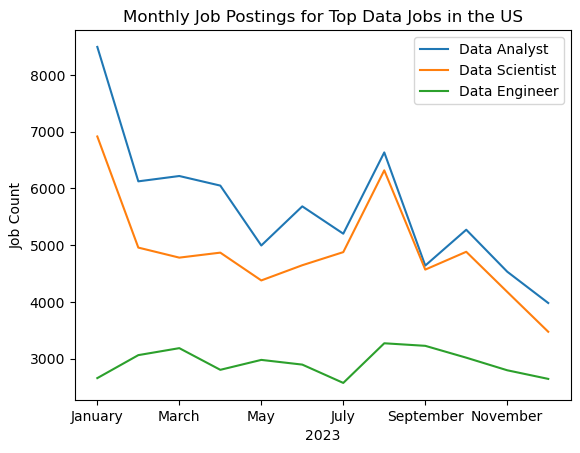

In [101]:
# Plotting the US Data Frame to see the Top 3 Jobs and Cleaning up the Visualization
df_US_pivot[top_3_US].plot(kind='line')
plt.title('Monthly Job Postings for Top Data Jobs in the US')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()

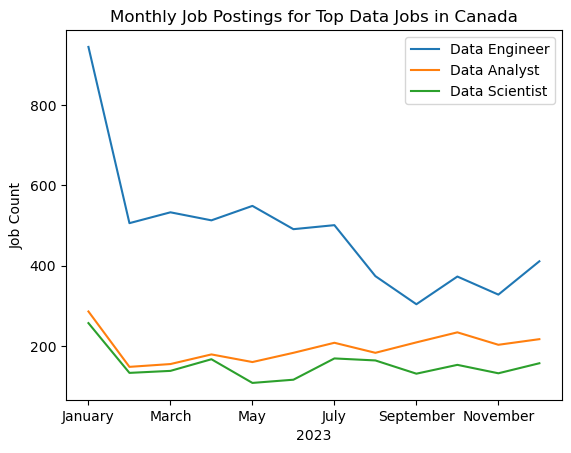

In [102]:
# Plotting the Canadian Data Frame to see the Top 3 Jobs and Cleaning up the Visualization
df_Canada_pivot[top_3_Canada].plot(kind='line')
plt.title('Monthly Job Postings for Top Data Jobs in Canada')
plt.xlabel('2023')
plt.ylabel('Job Count')
plt.legend()
plt.show()

- And now when we Print it out, we have our Top 3 Jobs
- Now it's not as Cluttered and we can actually do some Analysis on this

### Closing Remarks and Insights Learned
___
- Right now there's a super high Amount in January
- We can also see a burst in August for the US Market
    - January does make sense for the fact that that's normally when New Budgets are Approved for the Year and so they Ramp up Hiring
    - As far as August, we'd need to dive into this further to see why it's spiking. Potentially there was a New Budget Released?
        - Potentially, there were a lot of people changing Jobs/Careers and there was an influx in Postings
        - This is more like an outlier then an actual certainty as we can see, when Comparing the US Graph to the Canadian Graph
- Also, Engineers are very consistent, they don't Conform to the same Trends as Analyst and Scientist